In [1]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import math 

In [2]:
f1 = '../data/datos_notebook_final/investigadores_y_patentes.csv'
f2 = '../data/datos_notebook_final/desercion_estatal.csv'
f3 = '../data/datos_notebook_final/escolaridad.csv'

investigadores_y_patentes = pd.read_csv(f1)
desercion_estatal = pd.read_csv(f2)
escolaridad = pd.read_csv(f3)

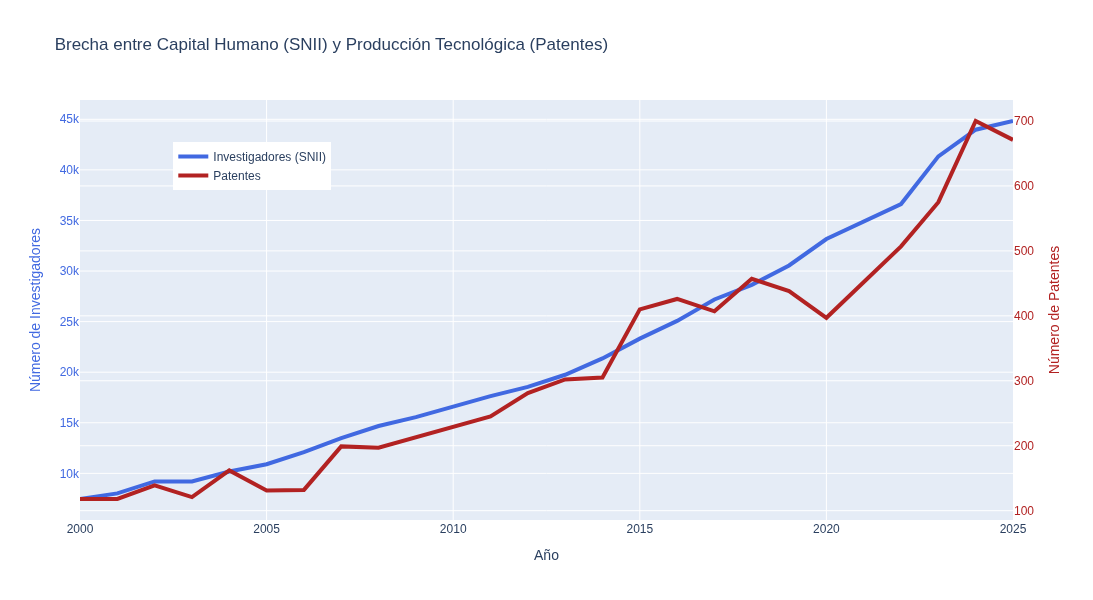

In [3]:
figura = go.Figure()

figura.add_trace(go.Scatter(
       x = investigadores_y_patentes['Año'], 
       y = investigadores_y_patentes['No_de_investigadores_reconocidos_por_el_snii'],
       name = "Investigadores (SNII)",
       line = dict(color='royalblue', width = 4)
))

figura.add_trace(go.Scatter(
       x = investigadores_y_patentes['Año'], 
       y = investigadores_y_patentes['no_patentes'],
       name = "Patentes",
       yaxis = "y2",
       line = dict(color = 'firebrick', width = 4)
))

figura.update_layout(
       title = 'Brecha entre Capital Humano (SNII) y Producción Tecnológica (Patentes)',
       xaxis = dict(title=dict(text='Año')),
       yaxis = dict(
           title = dict(
               text = 'Número de Investigadores',
               font = dict(color = "royalblue")
           ),
           tickfont = dict(color = "royalblue")
       ),
       yaxis2 = dict(
           title = dict(
               text = 'Número de Patentes',
               font = dict(color = "firebrick")
           ),
           tickfont = dict(color = "firebrick"),
           overlaying = 'y',
           side = 'right'
       ),
       legend = dict(x = 0.1, y = 0.9),
       width = 900,
       height = 600
)

figura.show()

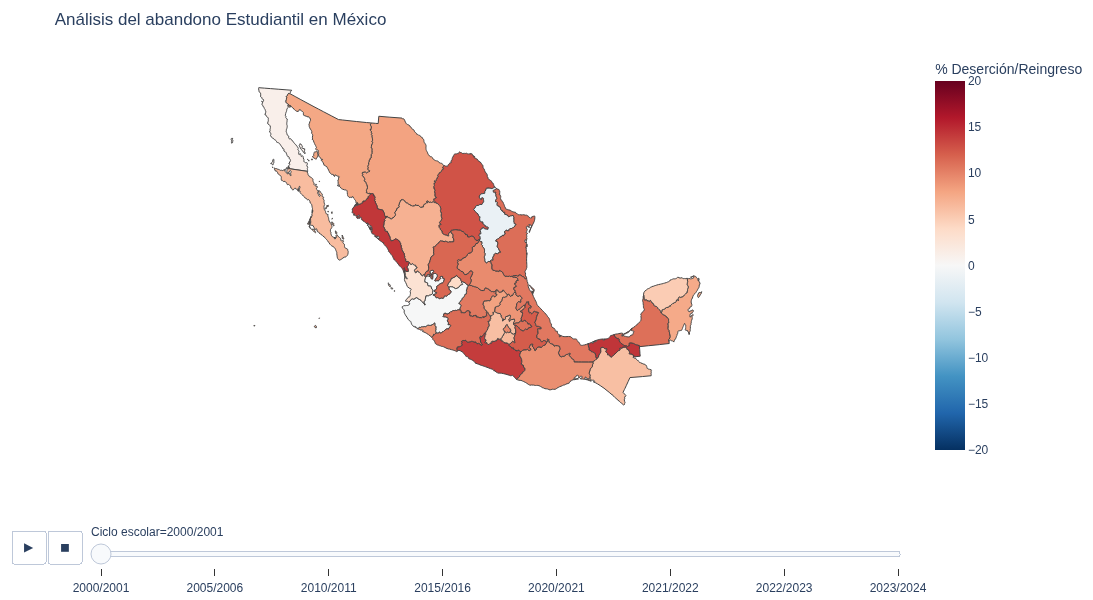

In [4]:
repo_url = 'https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json'

figura = px.choropleth(
       desercion_estatal,
       geojson = repo_url,
       locations = 'Entidad federativa',
       featureidkey = 'properties.name',
       color = 'Tasa de Deserción',
       animation_frame = 'Ciclo escolar',
       scope="north america",
       color_continuous_scale = "RdBu_r", 
       range_color = [-20, 20], 
       labels = {'Tasa de Deserción': '% Deserción/Reingreso'},
       title = 'Análisis del abandono Estudiantil en México',
       width = 800,  
       height = 600   
)


figura.update_geos(
       fitbounds = "locations", 
       visible=False
)

figura.update_layout(
       margin = {"r":0,"t":50,"l":0,"b":0}, 
)

figura.show()